# Appendix B: Macrodata Analysis (National Aggregates)
**Research Questions Addressed: RQ2 and RQ4**
This notebook contains the cross-sectional panel data regression and geospatial unsupervised clustering for national-level World Bank economic indicators.

### Phase 4: Data Ingestion and Indicator Auto-Mapping
The following code loads the Findex ZIP archive, dynamically searches the human-readable labels for exact infrastructural/resilience indicator codes, and pivots the dataset to create a unified feature matrix. Time-series gaps are forward-filled.

In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
from linearmodels.panel import PooledOLS

# 2. Load Macro Data Directly from ZIP
print("Loading macro dataset from ZIP archive...")
df_macro = pd.read_csv('../data/raw/WB_FINDEX.zip', compression='zip') 

# --- Data Preparation (Auto-Mapping Findex Indicators) ---
print("Scanning dataset for appropriate Findex Indicators...")

# Dynamically find the specific Findex codes using the human-readable labels
target_df = df_macro[df_macro['INDICATOR_LABEL'].str.contains('Account ownership', case=False, na=False)]
target_code = target_df['INDICATOR'].values[0]

tech_df = df_macro[df_macro['INDICATOR_LABEL'].str.contains('Mobile money account', case=False, na=False)]
tech_code = tech_df['INDICATOR'].values[0]

res_df = df_macro[df_macro['INDICATOR_LABEL'].str.contains('emergency funds', case=False, na=False)]
res_code = res_df['INDICATOR'].values[0]

print(f"✓ Found Target Code: {target_code}")
print(f"✓ Found Tech Proxy: {tech_code}")
print(f"✓ Found Resilience Proxy: {res_code}")

Loading macro dataset from ZIP archive...
Scanning dataset for appropriate Findex Indicators...
✓ Found Target Code: WB_FINDEX_ACCOUNT_T_D
✓ Found Tech Proxy: WB_FINDEX_FIN14D
✓ Found Resilience Proxy: WB_FINDEX_FIN24AN


In [2]:
# Pivot the table using the discovered codes
df_pivot = df_macro[df_macro['INDICATOR'].isin([target_code, tech_code, res_code])].pivot_table(
    index=['REF_AREA', 'TIME_PERIOD'], 
    columns='INDICATOR', 
    values='OBS_VALUE',
    aggfunc='mean'
).reset_index()

# Rename columns to match our modeling workflow
df_pivot.rename(columns={
    tech_code: 'internet_penetration',
    res_code: 'resilience_index',       
    target_code: 'digital_account_penetration' 
}, inplace=True)

# Safely forward-fill ONLY the value columns so REF_AREA and TIME_PERIOD aren't dropped
cols_to_fill = ['internet_penetration', 'resilience_index', 'digital_account_penetration']
df_pivot[cols_to_fill] = df_pivot.groupby('REF_AREA')[cols_to_fill].ffill()

# Drop any rows that still have NaNs after forward filling
df_clean = df_pivot.dropna(subset=cols_to_fill)

### Phase 5: Panel Data Regression (RQ2)
Testing the statistical association between national economic resilience, internet penetration, and digital banking adoption. Because the dataset acts as a sparse cross-sectional wave, a **Pooled OLS Regression with clustered standard errors** is utilized.

In [3]:
# ==========================================
# RQ2: Panel Data Regression
# ==========================================
print("\n--- Executing RQ2: Panel Data Regression ---")

# Set Multi-Index for PanelOLS (Entity = Country/Region, Time = Year)
panel_data = df_clean.set_index(['REF_AREA', 'TIME_PERIOD'])

# Define independent variables (exog) and dependent variable (endog)
exog_vars = ['internet_penetration', 'resilience_index']

# Add a constant (intercept) which is required for Pooled OLS
exog = sm.add_constant(panel_data[exog_vars])
endog = panel_data['digital_account_penetration']

# Because Findex survey waves are sparse (time-invariant between waves), 
# Fixed Effects fails. We use Pooled OLS with clustered standard errors instead.
mod = PooledOLS(endog, exog)
res = mod.fit(cov_type='clustered', cluster_entity=True)

print(res.summary)


--- Executing RQ2: Panel Data Regression ---
                               PooledOLS Estimation Summary                              
Dep. Variable:     digital_account_penetration   R-squared:                        0.6678
Estimator:                           PooledOLS   R-squared (Between):              0.6678
No. Observations:                           37   R-squared (Within):               0.0000
Date:                         Sat, May 16 2026   R-squared (Overall):              0.6678
Time:                                 22:46:20   Log-likelihood                   -135.49
Cov. Estimator:                      Clustered                                           
                                                 F-statistic:                      34.179
Entities:                                   37   P-value                           0.0000
Avg Obs:                                1.0000   Distribution:                    F(2,34)
Min Obs:                                1.0000        

### Phase 6: Unsupervised Geospatial Clustering (RQ4)
Scaling the macroeconomic feature matrix to identify global infrastructural tiers. K-Means is deployed using $k=3$ (validated via the Elbow Method), while DBSCAN is tuned to isolate non-spherical outliers and underdeveloped data points.


--- Executing RQ4: Geospatial Clustering ---


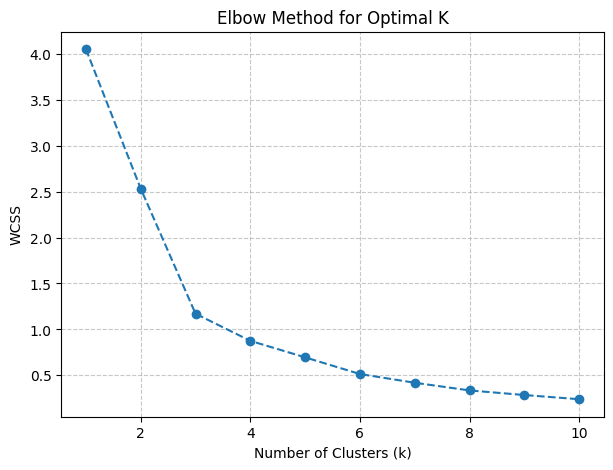

In [4]:
# ==========================================
# RQ4: Unsupervised Clustering (K-Means & DBSCAN)
# ==========================================
print("\n--- Executing RQ4: Geospatial Clustering ---")

# Filter for the most recent year to cluster current infrastructure
latest_year = df_clean['TIME_PERIOD'].max()
df_clust = df_clean[df_clean['TIME_PERIOD'] == latest_year].copy()

# Features to cluster on
X_clust = df_clust[['internet_penetration', 'resilience_index']]

# Scale data strictly between 0 and 1 for distance-based algorithms
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_clust)

# --- A. K-Means Elbow Method ---
wcss =[]
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

K-Means Silhouette Score: 0.476
K-Means Davies-Bouldin Index: 0.691


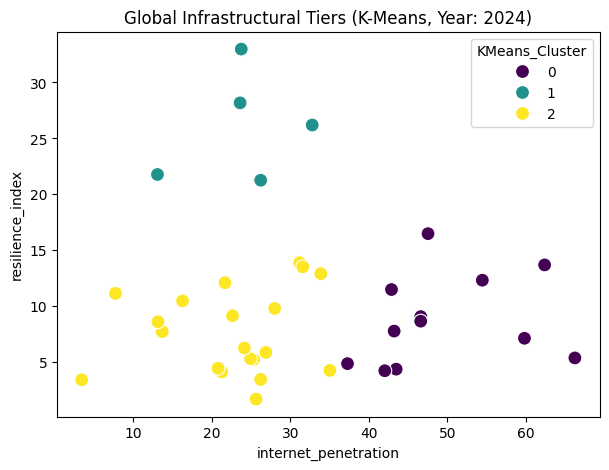

In [5]:
# Fit K-Means with k=3 
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clust['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

sil_k = silhouette_score(X_scaled, df_clust['KMeans_Cluster'])
db_k = davies_bouldin_score(X_scaled, df_clust['KMeans_Cluster'])
print(f"K-Means Silhouette Score: {sil_k:.3f}")
print(f"K-Means Davies-Bouldin Index: {db_k:.3f}")

# Plot K-Means Clusters
plt.figure(figsize=(7,5))
sns.scatterplot(x='internet_penetration', y='resilience_index', hue='KMeans_Cluster', 
                palette='viridis', data=df_clust, s=100)
plt.title(f'Global Infrastructural Tiers (K-Means, Year: {latest_year})')
plt.show()

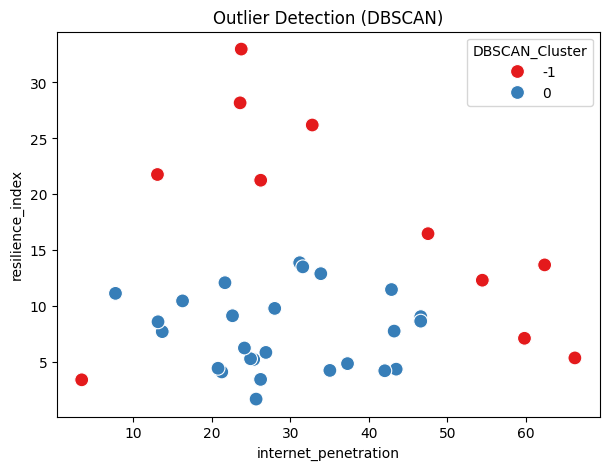

In [6]:
# --- B. DBSCAN ---
# eps and min_samples tuned to find non-spherical outliers
dbscan = DBSCAN(eps=0.15, min_samples=5)
df_clust['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Plot DBSCAN Clusters (-1 represents outliers)
plt.figure(figsize=(7,5))
sns.scatterplot(x='internet_penetration', y='resilience_index', hue='DBSCAN_Cluster', 
                palette='Set1', data=df_clust, s=100)
plt.title('Outlier Detection (DBSCAN)')
plt.show()